# `multilayer_fold` — strat-column → GeoModel (Curlew / GeoINR integration)

End-to-end verification of the depositional path of the GeoINR → Curlew
integration (SPEC §6.1). A six-unit conformable sequence (A–F) is parsed from a
stratigraphic-column CSV, partitioned into a **single depositional scalar field**
with five internal contacts, fitted with a **Siren** neural field, and checked.

Pipeline: **load & normalize → partition (visual) → constraints (visual) → fit →
predict & 3D view → checks**.

The builder (`curlew.geology.stratbuilder.build_geomodel`) and observation loader
(`curlew.io.loadObservations`) are the newly ported pieces; everything else reuses
Curlew's native events / `CSet` constraints / seed isosurfaces / `Transform`.

## 0. Setup

In [1]:
%matplotlib inline
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import curlew
from curlew.io import loadObservations
from curlew.geology.stratbuilder import build_geomodel

# --- compute on the GPU -----------------------------------------------------
# This notebook runs on the GPU. Override with the env var CURLEW_DEVICE=cpu
# only for headless/CI execution on a machine without a CUDA device.
DEVICE = os.environ.get("CURLEW_DEVICE", "cuda")
if DEVICE.startswith("cuda") and not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU requested but torch.cuda.is_available() is False. "
        "Install a CUDA-enabled torch / driver, or set CURLEW_DEVICE=cpu to run on CPU."
    )
curlew.device = DEVICE
# float64 is Curlew's default; drop to float32 to save GPU memory if needed.
# curlew.dtype = torch.float32

# deterministic run (network initialisation)
torch.manual_seed(0)
np.random.seed(0)

# locate the GeoINR reference dataset
CANDIDATES = [
    r"D:/Development/GeoINR_Research2/geoinr/data/multilayer_fold",
    os.path.join(os.path.dirname(os.getcwd()), "data", "multilayer_fold"),
    "./data/multilayer_fold",
]
DATA = next((p for p in CANDIDATES if os.path.exists(os.path.join(p, "strat_col.csv"))), None)
assert DATA is not None, f"Could not locate multilayer_fold data; tried {CANDIDATES}"
STRAT_CSV = os.path.join(DATA, "strat_col.csv")
print("device:", curlew.device, "| dtype:", curlew.dtype)
print("data:", DATA)

device: cuda | dtype: torch.float64
data: D:/Development/GeoINR_Research2/geoinr/data/multilayer_fold


## 1. Load & normalize

Read the strat column and the point observations (`interface.vtp` contact points
+ `normal.vtp` oriented normals) and build the model on **all** observations — a
single curlew model is fit to all available data (no train/validation holdout).
`build_geomodel` computes the data bounds and attaches an **isometric**
normalization `Transform` into `[-1, 1]`.

In [2]:
obs = loadObservations(
    interfaces=os.path.join(DATA, "interface.vtp"),
    normals=os.path.join(DATA, "normal.vtp"),
)
print("observations:", len(obs), "points |", obs.ndim, "D")
print("interface points:", obs.interface_points()[0].shape[0],
      "across levels", obs.levels("interface"))
print("normal points:", obs.normal_points()[0].shape[0])

# Siren hyperparameters are forwarded to the field's `initField` via `field_kwargs`.
# `omega0`/`omega` set the sine-layer frequencies (lower = smoother field);
# learning_rate=1e-4 is the Siren default.
SIREN_KWARGS = dict(omega0=2.0, omega=30.0, learning_rate=1e-4, hidden_dim=256)
M = build_geomodel(STRAT_CSV, obs, field="Siren", scale="isometric",
                   field_kwargs=SIREN_KWARGS)
T = M.normalization

observations: 117 points | 3 D
interface points: 67 across levels [0, 1, 2, 3, 4]
normal points: 50


In [3]:
# parsed stratigraphic column (youngest-first, as in the CSV)
try:
    import pandas as pd
    col = pd.DataFrame([
        {"index": i, "name": u.name, "relation": u.relation, "level": u.level}
        for i, u in enumerate(M.strat_units)
    ])
    display(col)
except Exception:
    for i, u in enumerate(M.strat_units):
        print(i, u.name, u.relation, u.level)

print("\nnormalization Transform (global → model):")
print(np.array2string(T.matrix, precision=4, suppress_small=True))

,index,name,relation,level
0,0,A,conformal,5
1,1,B,conformal,4
2,2,C,conformal,3
3,3,D,conformal,2
4,4,E,conformal,1
5,5,F,conformal,0



normalization Transform (global → model):
[[ 0.0083  0.      0.     -0.1438]
 [ 0.      0.0083  0.     -0.2834]
 [ 0.      0.      0.0083 -1.0003]
 [ 0.      0.      0.      1.    ]]


**Reading the transform.** It is a single homogeneous *scale + translate* that
maps world coordinates into the model box. For `scale="isometric"` the diagonal is
one shared factor `s = 2 / max(extent_x, extent_y, extent_z)` (here `≈0.0083`), and
the translation re-centres the data on the origin. So the **longest** axis is mapped
to exactly `[-1, 1]` (`extent · s = 2`), and the shorter axes map to proportionally
**smaller** sub-ranges (they keep the same units, so the model stays undistorted).
`scale="geo_extensive"` instead uses a separate xy and z factor (vertical
exaggeration). The cell below prints the actual per-axis ranges after normalization.

In [4]:
lo, hi = obs.bounds()
lo = np.asarray(lo, float); hi = np.asarray(hi, float)
# transform the 8 bounding-box corners into model space
import itertools
corners = np.array(list(itertools.product(*zip(lo, hi))), dtype=float)
mc = T.apply(corners)
for ax, name in enumerate("xyz"[:obs.ndim]):
    print(f"  {name}: world [{lo[ax]:8.2f}, {hi[ax]:8.2f}]  (extent {hi[ax]-lo[ax]:7.2f})"
          f"   →  model [{mc[:,ax].min():6.3f}, {mc[:,ax].max():6.3f}]")
print("\nLongest world axis maps to the full [-1, 1]; shorter axes stay proportionally smaller.")

  x: world [  -76.22,   110.72]  (extent  186.94)   →  model [-0.779,  0.779]
  y: world [  -23.00,    91.02]  (extent  114.02)   →  model [-0.475,  0.475]
  z: world [    0.03,   240.00]  (extent  239.97)   →  model [-1.000,  1.000]

Longest world axis maps to the full [-1, 1]; shorter axes stay proportionally smaller.


## 2. Scalar-field partitioning (visual)

How the six units are partitioned into Curlew events. All units are `conformal`,
so the partitioner emits **one depositional field** carrying five internal
contacts (the tops of B–F). The diagram is oldest→youngest.

derived scalar fields (oldest → youngest):
  scalar_field0  kind=depositional  units=[0, 1, 2, 3, 4, 5]
     contact 'F'  level=0  n_points=16
     contact 'E'  level=1  n_points=13
     contact 'D'  level=2  n_points=14
     contact 'C'  level=3  n_points=12
     contact 'B'  level=4  n_points=12


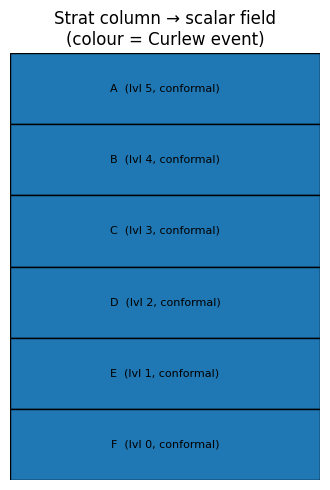

In [5]:
print("derived scalar fields (oldest → youngest):")
for meta in M.field_meta:
    cs = sorted(meta.contacts, key=lambda c: c.unit_index, reverse=True)  # oldest→youngest
    print(f"  {meta.name}  kind={meta.kind}  units={meta.unit_indices}")
    for c in cs:
        print(f"     contact '{c.name}'  level={c.level}  n_points={c.n_points}")

# stratigraphic-column diagram, colour-coded by scalar field
units = M.strat_units
n = len(units)
field_of = {ui: k for k, meta in enumerate(M.field_meta) for ui in meta.unit_indices}
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(3.4, 5))
for i, u in enumerate(units):              # i=0 youngest at top
    y = n - 1 - i
    fid = field_of.get(i, -1)
    ax.add_patch(plt.Rectangle((0, y), 1, 1,
                 facecolor=cmap(fid % 10) if fid >= 0 else "lightgray",
                 edgecolor="k"))
    ax.text(0.5, y + 0.5, f"{u.name}  (lvl {u.level}, {u.relation})",
            ha="center", va="center", fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, n); ax.axis("off")
ax.set_title("Strat column → scalar field\n(colour = Curlew event)")
plt.tight_layout(); plt.show()

**GeoModel event graph** (`_repr_svg_`):

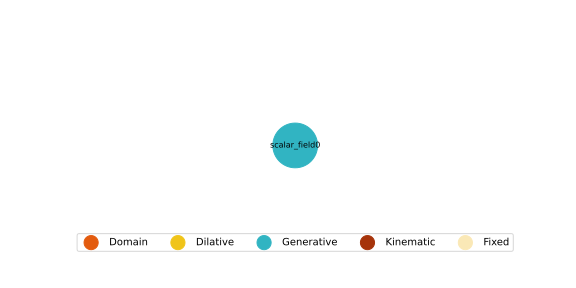

In [6]:
M

## 3. Constraint relations (visual)

The constraints that wire the geological features together. They are plotted here
in **world (global) coordinates** for clarity:

- **`eq` traces / seed isosurfaces** — interface points coloured by contact (each
  contact is one equal-value level set + one seed isosurface), with the **`gv`**
  bedding normals (younging direction) drawn as arrows;
- **`iq` inequalities** — one per contact pair (`C(5,2) = 10`), each enforcing the
  younger contact's field value `>` the older contact's (the reverse `<` is then
  automatic, so only one direction is stored). The `iq pools` count is printed below.

With a GeoINR-family field (as here) both are consumed by GeoINR's
**gradient-normalised** losses on the field itself — interface: `|Δf|/‖∇f‖` between
points of the same contact; inequality: the hinged `(f(P1)−f(P2))/‖∇f(P1)‖` — so the
residuals behave like distances and the field cannot shrink its output range to
satisfy them trivially. Only the bedding-normal (`grad_loss`) term uses the generic
`HSet`.

**On the normals.** The builder stores constraints in *model* coordinates, but the
normalization here is **isometric** (a uniform scale + translate), which **preserves
directions** — so the bedding-normal vectors are identical in world and model space
(only their attachment points are rescaled). The model uses the raw unit normals as
`gv`; nothing rotates them. (Under an *anisotropic* `geo_extensive` scaling the
direction would change and would need the inverse-transpose mapping — but
`multilayer_fold` is isometric and `wcsb` carries no normals.)

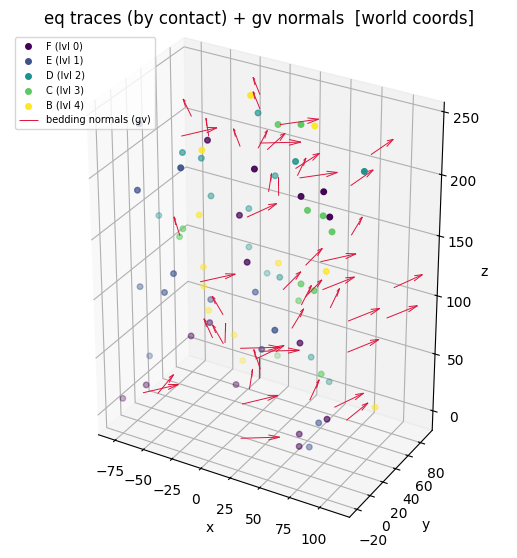

CSet: eq traces=5  gv normals=50  iq pools=10
HSet (generic terms): {'eq_loss': 0, 'grad_loss': 1.0, 'iq_loss': 0}
GeoINR loss weights: {'eq_norm_weight': 1.0, 'iq_norm_weight': 1.0, 'overturn_weight': 0.0}


In [7]:
ev = M.events[0]
C = ev.field.C            # bound CSet (model coords)
contacts = sorted(M.field_meta[0].contacts, key=lambda c: c.unit_index, reverse=True)
nco, nvec, _ = obs.normal_points()
nvec_u = nvec / np.linalg.norm(nvec, axis=1, keepdims=True)
arrow_len = 0.12 * float(np.max(hi - lo))   # ~12% of the largest extent

# eq traces (interface points by contact) + gv normals — world coordinates
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(projection="3d")
for k, c in enumerate(contacts):
    p = obs.coords[obs.is_interface & (obs.level == c.level)]
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=16, color=plt.get_cmap("viridis")(k/4),
               label=f"{c.name} (lvl {c.level})")
ax.quiver(nco[:, 0], nco[:, 1], nco[:, 2],
          nvec_u[:, 0], nvec_u[:, 1], nvec_u[:, 2],
          length=arrow_len, color="crimson", linewidth=0.7, normalize=True,
          label="bedding normals (gv)")
ax.set_title("eq traces (by contact) + gv normals  [world coords]")
ax.legend(fontsize=7, loc="upper left")
ax.set_box_aspect((hi[0]-lo[0], hi[1]-lo[1], hi[2]-lo[2]))
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
plt.tight_layout(); plt.show()

n_iq = 0 if C.iq is None else len(C.iq[1])
print(f"CSet: eq traces={0 if C.eq is None else len(C.eq)}  "
      f"gv normals={0 if C.gp is None else C.gp.shape[0]}  iq pools={n_iq}")
print("HSet (generic terms):", {k: getattr(ev.field.H, k) for k in
      ['eq_loss', 'grad_loss', 'iq_loss']})
print("GeoINR loss weights:", {k: getattr(ev.field, k) for k in
      ['eq_norm_weight', 'iq_norm_weight', 'overturn_weight']})

## 4. Fit

Train the Siren field on all bound constraints with a single `M.fit(...)` call.
`M.fit` returns the final loss and a `Pebble` (the final per-term breakdown). Passing
`history=True` additionally returns one detached `Pebble` **per epoch** — that's the
loss curve. `M.fit` shows a `tqdm` progress bar while it runs (`vb=True` by default).

Training            0/2000 

final loss: 0.002135771246005731
L=0.002 grad_loss=0.000 eq_norm_loss=0.002


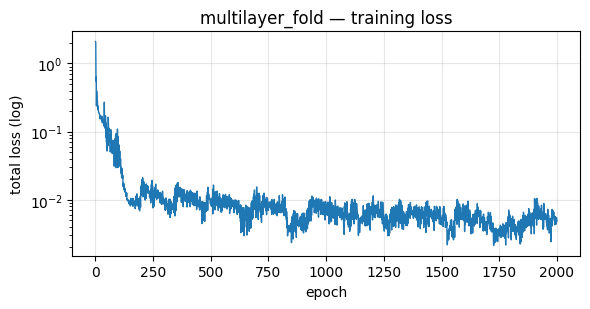

In [8]:
N_EPOCHS = 2000
loss, pebble, history = M.fit(N_EPOCHS, early_stop=None, best=False, history=True)
print("final loss:", loss)
print(pebble)                                   # final per-term breakdown

# history is a list of per-epoch Pebbles; total() gives each epoch's loss
losses = [p.total() for p in history]
plt.figure(figsize=(6, 3.2))
plt.plot(np.arange(1, len(losses) + 1), losses, lw=1)
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("total loss (log)")
plt.title("multilayer_fold — training loss"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Predict & 3D view (napari)

Evaluate the fitted model on a regular grid → `Geode`, then open a **napari** 3D
view: the scalar-field volume, the predicted **units** (lithology IDs) and one
extracted **iso-surface mesh per contact**. Following the idiomatic curlew pattern,
the scalar volume and the surfaces are pushed as **separate layers** (`addVolume` +
per-contact `G.contour` → `addMesh`). `SHOW_NAPARI` is on by default. A matplotlib
cross-section follows as a static fallback so the notebook still renders without a
live Qt session.

In [9]:
from curlew.geometry import Grid
lo, hi = obs.bounds()
lo = np.asarray(lo, float); hi = np.asarray(hi, float)
ext = hi - lo
center = 0.5 * (lo + hi)
G = Grid(dims=tuple(ext), step=tuple(ext / 48.0), center=tuple(center))
geode = M.predict(G)
print("grid shape:", geode.grid.shape, "| scalar range:",
      float(np.nanmin(geode.scalar)), "→", float(np.nanmax(geode.scalar)))

grid shape: (48, 48, 48) | scalar range: -50.1305101880829 → 56.16636919868815


In [10]:
SHOW_NAPARI = True   # set False to skip opening the napari window
if SHOW_NAPARI:
    from curlew.visualise.napari_viewer import NapariViewer
    nv = NapariViewer(title="multilayer_fold", ndisplay=3)

    # one colour per contact, shared by its iso-surface mesh AND its interface points
    contacts_ord = sorted(M.field_meta[0].contacts, key=lambda c: c.unit_index, reverse=True)
    nC = len(contacts_ord)
    contact_color = {c.name: np.asarray(curlew.ccramp(i / max(nC - 1, 1)))
                     for i, c in enumerate(contacts_ord)}

    # (1) scalar-field volume. 'attenuated_mip' renders a smooth field and avoids
    # the napari hover bug that 'translucent'/'iso' can trigger when the cursor ray
    # misses the volume (a harmless IndexError in the status bar).
    nv.addVolume("scalar", G.reshape(geode.scalar), grid=G,
                 rendering="attenuated_mip", colormap=curlew.ccstrat)

    # (2) predicted units (lithology IDs) as an additive volume
    nv.addVolume("units", G.reshape(geode.lithoID.astype(float)), grid=G,
                 rendering="additive", blending="additive",
                 colormap=curlew.ccstrat, opacity=0.4)

    # (3) one iso-surface mesh per contact — extracted with G.contour, pushed via
    # addMesh (the idiomatic curlew pattern: scalar + meshes added as separate layers).
    for e in M.events:
        if e.overprint is None:
            continue
        mask = geode.structureID == e.eid          # restrict to this event's region
        for name, iso in e.getIsovalues().items():
            verts, faces = G.contour(geode.fields[e.name], iso=iso, mask=mask, erodeMask=-4)
            nv.addMesh(name, verts=verts, faces=faces, rgb=contact_color[name])

    # (4) interface (contact) points — coloured to match each contact's surface
    for c in contacts_ord:
        p = obs.coords[obs.is_interface & (obs.level == c.level)]
        nv.addPoints(f"pts_{c.name}", p, rgb=np.tile(contact_color[c.name], (len(p), 1)),
                     size=6.0, border_color="black")

    # (5) bedding normals (the gv gradient constraints) as vectors
    nco, nvec, _ = obs.normal_points()
    nvec_u = nvec / np.linalg.norm(nvec, axis=1, keepdims=True)
    nv.addVectors("normals", origins=nco, directions=nvec_u, rgb="crimson",
                  length=0.10 * float(np.max(hi - lo)), width=1.5)

    nv.show()
    # If the window is not responsive in VS Code / Jupyter, enable the Qt event loop
    # once per session with the `%gui qt` line magic (or call `napari.run()`).
    print(f"napari viewer: 'scalar' + 'units' volumes, {nC} contact iso-surfaces, "
          f"interface points (pts_*) and bedding normals.")

napari viewer: 'scalar' + 'units' volumes, 5 contact iso-surfaces, interface points (pts_*) and bedding normals.


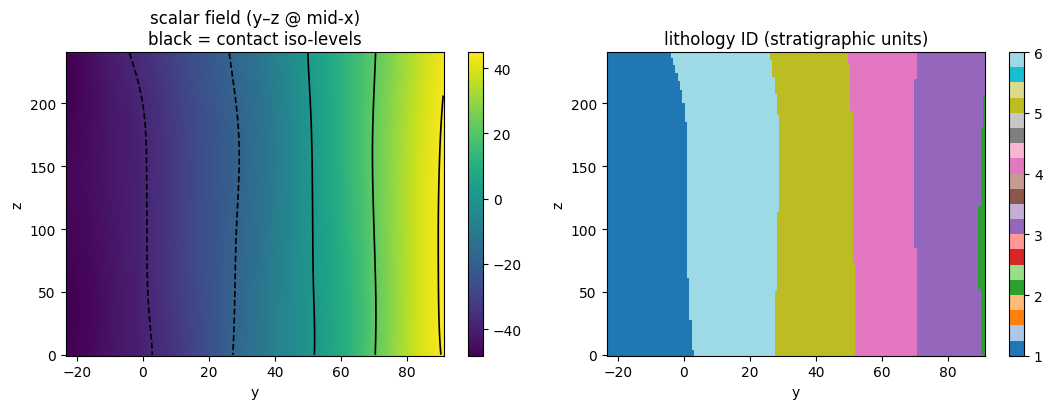

In [11]:
# static matplotlib cross-section (y–z plane at mid-x), with contact iso-contours
ny = nz = 160
ys = np.linspace(lo[1], hi[1], ny)
zs = np.linspace(lo[2], hi[2], nz)
YY, ZZ = np.meshgrid(ys, zs)
XX = np.full_like(YY, center[0])
pts = np.stack([XX, YY, ZZ], axis=-1).reshape(-1, 3).astype(float)
sec = M.predict(pts)
S = sec.scalar.reshape(nz, ny)
isovals = [ev.getIsovalue(c.name) for c in contacts]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
pcm = ax[0].pcolormesh(ys, zs, S, shading="auto", cmap="viridis")
ax[0].contour(ys, zs, S, levels=sorted(isovals), colors="k", linewidths=1.2)
fig.colorbar(pcm, ax=ax[0]); ax[0].set_title("scalar field (y–z @ mid-x)\nblack = contact iso-levels")
ax[0].set_xlabel("y"); ax[0].set_ylabel("z")
L = sec.lithoID.reshape(nz, ny)
pcm2 = ax[1].pcolormesh(ys, zs, L, shading="auto", cmap="tab20")
fig.colorbar(pcm2, ax=ax[1]); ax[1].set_title("lithology ID (stratigraphic units)")
ax[1].set_xlabel("y"); ax[1].set_ylabel("z")
plt.tight_layout(); plt.show()

## 6. Checks (SPEC §6.1)

1. The five recovered iso-values (from seeds) are **strictly monotonic** in
   stratigraphic order.
2. At the interface points, the predicted scalar ≈ the contact iso-value
   (each point lands nearest its own contact; mean error small vs contact spacing).
3. Predicted gradient at normal points **aligns** with the supplied normals
   (positive dot / small angular error).

In [12]:
results = {}

# --- Check 1: monotonic iso-values in stratigraphic order (oldest → youngest) ---
contacts_strat = sorted(M.field_meta[0].contacts, key=lambda c: c.unit_index, reverse=True)
isovals = np.array([ev.getIsovalue(c.name) for c in contacts_strat])
d = np.diff(isovals)
mono = bool(np.all(d > 0) or np.all(d < 0))
print("Check 1 — recovered iso-values (oldest→youngest):",
      np.array2string(isovals, precision=3))
print(f"         strictly monotonic: {mono}")
results["monotonic_iso"] = mono

# --- Check 2: predicted ≈ iso at the (all) interface points the model was fit to ---
min_gap = float(np.min(np.abs(d)))
errs, nearest_ok = [], []
for c in M.field_meta[0].contacts:
    iso = ev.getIsovalue(c.name)
    hp = obs.coords[obs.is_interface & (obs.level == c.level)].astype(float)
    if len(hp) == 0:
        continue
    s = M.predict(hp).scalar
    errs.extend(np.abs(s - iso).tolist())
    nearest = [contacts_strat[int(np.argmin(np.abs(isovals - v)))].name == c.name for v in s]
    nearest_ok.extend(nearest)
errs = np.array(errs)
mean_err = float(errs.mean()); rmse = float(np.sqrt((errs ** 2).mean()))
acc = float(np.mean(nearest_ok))
ok2 = (acc >= 0.9) and (mean_err < 0.5 * min_gap)
print(f"\nCheck 2 — interface points (n={len(errs)}): "
      f"mean|err|={mean_err:.3f}, rmse={rmse:.3f}, min contact gap={min_gap:.3f}")
print(f"         mean error = {100*mean_err/min_gap:.0f}% of min gap; "
      f"nearest-contact accuracy = {acc:.2f}")
print(f"         pass (acc≥0.9 and mean<0.5·gap): {ok2}")
results["interface_predict"] = ok2

# --- Check 3: predicted gradient aligns with supplied normals ---
nco, nvec, _ = obs.normal_points()
nvec = nvec / (np.linalg.norm(nvec, axis=1, keepdims=True) + 1e-12)
g = ev.gradient(T.apply(nco.astype(float)), normalize=True, transform=False)
dots = np.sum(g * nvec, axis=1)
ang = np.degrees(np.arccos(np.clip(dots, -1, 1)))
ok3 = bool(dots.mean() > 0.95 and (dots > 0).mean() == 1.0)
print(f"\nCheck 3 — gradient vs normals: mean dot={dots.mean():.3f}, "
      f"min dot={dots.min():.3f}, mean angle={ang.mean():.2f} deg, frac>0={(dots>0).mean():.2f}")
print(f"         pass (mean dot>0.95, all positive): {ok3}")
results["gradient_alignment"] = ok3

print("\n" + "=" * 48)
print("SPEC §6.1 CHECKS:", "ALL PASS ✅" if all(results.values()) else "FAILURE ❌")
for k, v in results.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")
assert all(results.values()), "One or more §6.1 checks failed."
print("=" * 48)

Check 1 — recovered iso-values (oldest→youngest): [-38.181 -18.789   1.41   21.798  43.841]
         strictly monotonic: True

Check 2 — interface points (n=67): mean|err|=0.573, rmse=0.713, min contact gap=19.391
         mean error = 3% of min gap; nearest-contact accuracy = 1.00
         pass (acc≥0.9 and mean<0.5·gap): True

Check 3 — gradient vs normals: mean dot=1.000, min dot=0.998, mean angle=1.45 deg, frac>0=1.00
         pass (mean dot>0.95, all positive): True

SPEC §6.1 CHECKS: ALL PASS ✅
  PASS  monotonic_iso
  PASS  interface_predict
  PASS  gradient_alignment
